# Data Preparation

Load all necessary packages for this notebook.

In [1]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (24, 12)

### Cropping and Size Standardization

In this section, we want to achieve 2 things:
1. The images come in slightly varying shapes and sizes. We want to standardize them as ML models typically only accept fixed input shapes.
2. The images contain a lot of meta data surrounding the actual ultrasound image. We want to remove them and just isolate the ultrasound image.

Lets load a sample image.

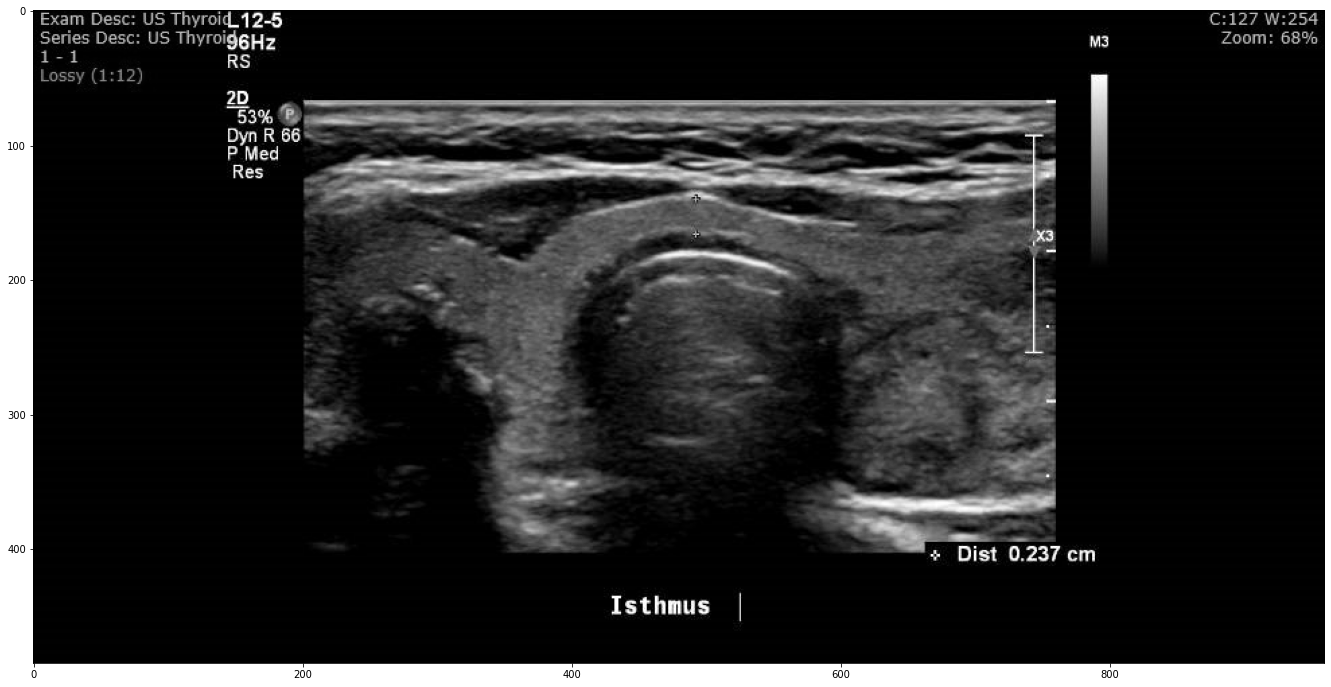

In [2]:
def load_image(image_path):
    img = cv2.imread(image_path, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img_rgb

image_path = os.path.join('..', 'data', 'singhealth', '255', '1.png')
image_array = load_image(image_path)
plt.imshow(image_array, 'gray')
plt.show()

We'll start with trying to isolate the ultrasound image. This goes hand in hand with the next section of artifact removal by removing the main bulk of miscellaneous information from the image. When we train a model to understand ultrasound images, we do not want to risk it instead learning from the metadata, which would greatly affect its robustness and generalizability to different machines.

Our approach is simple - We want to count the number of non-black pixels in each row and column. This is an intuitive approach as the ultrasound image is a large region of non-black pixels. The words surrounding the ultrasound image actually only correspond to a small number of non-black pixels.

The first step is to convert the image into a binary mask where non-black pixels are coded as 1 and black pixels are coded as 0. Next is to then find the mean of each row and column of this binary mask to find the average number of non-black pixels in the original image.

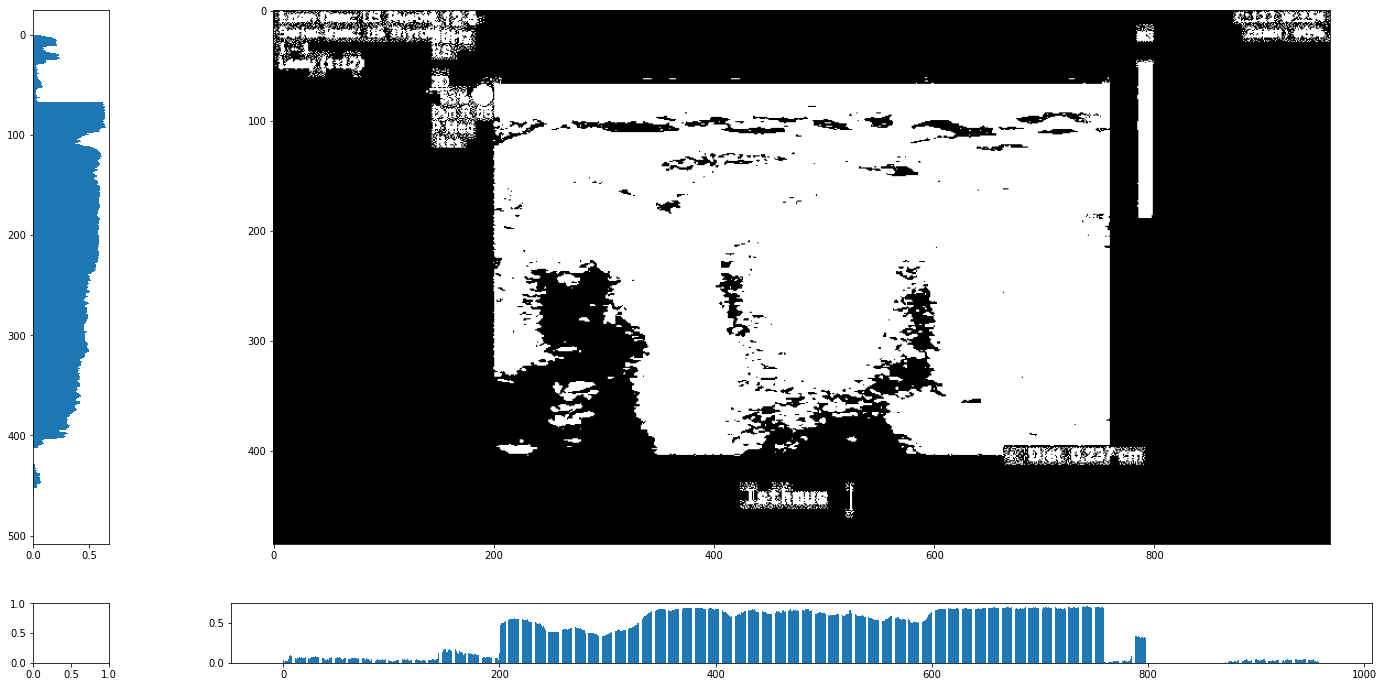

In [3]:
binary_mask = np.zeros(image_array.shape)
binary_mask[image_array > 4] = 1.

col_means = np.mean(binary_mask, axis=0)
row_means = np.mean(binary_mask, axis=1)

fig, axs = plt.subplots(2, 2, gridspec_kw={'width_ratios': [1, 15], 'height_ratios': [9, 1]})
axs[0, 0].barh(range(len(row_means)), row_means)
axs[0, 0].invert_yaxis()
axs[0, 1].imshow(binary_mask, 'gray')
axs[1, 1].bar(range(len(col_means)), col_means)
plt.show()

We can already see that this approach works pretty well. Just looking at the bar charts, we are able to determine where the ultrasound image is.

What can we do from here? We could simply use a threshold and pick the first and last row/column that exceeds the threshold. This would work well for this sample using an appropriate threshold, but it does not guarantee that it'll work for all images. Some images have artifacts that are much larger, which cause large spikes that are picked up instead.

Can we do better than a simple threshold? Yes we can. Lets focus on the left barchart. We notice that if we can somehow ignore the spikes, and just find the region of sustained exceeding of the threshold, we then have solved our problem. To tackle this, we will use the concept of runs.

Runs are the continuous occurrences of an event.

Lets say we have the follow list:

[0,1,1,0,2,5,4,2,7,8,6,9,2,1]

If we want to find the runs of elements greater than 3, it'll look something like this:

[0,0,0,0,0,1,2,0,1,2,3,4,0,0]

This allows us to determine how long the threshold has been crossed continuously. Above is an example of unidirectional runs since we're going from left to right. But in this case, we're going to be using bidirectional runs. Specifically, we are going to find the runs of rows/columns with at least an average of 18% of pixels being non-white. 18% is determined from trial-and-error.

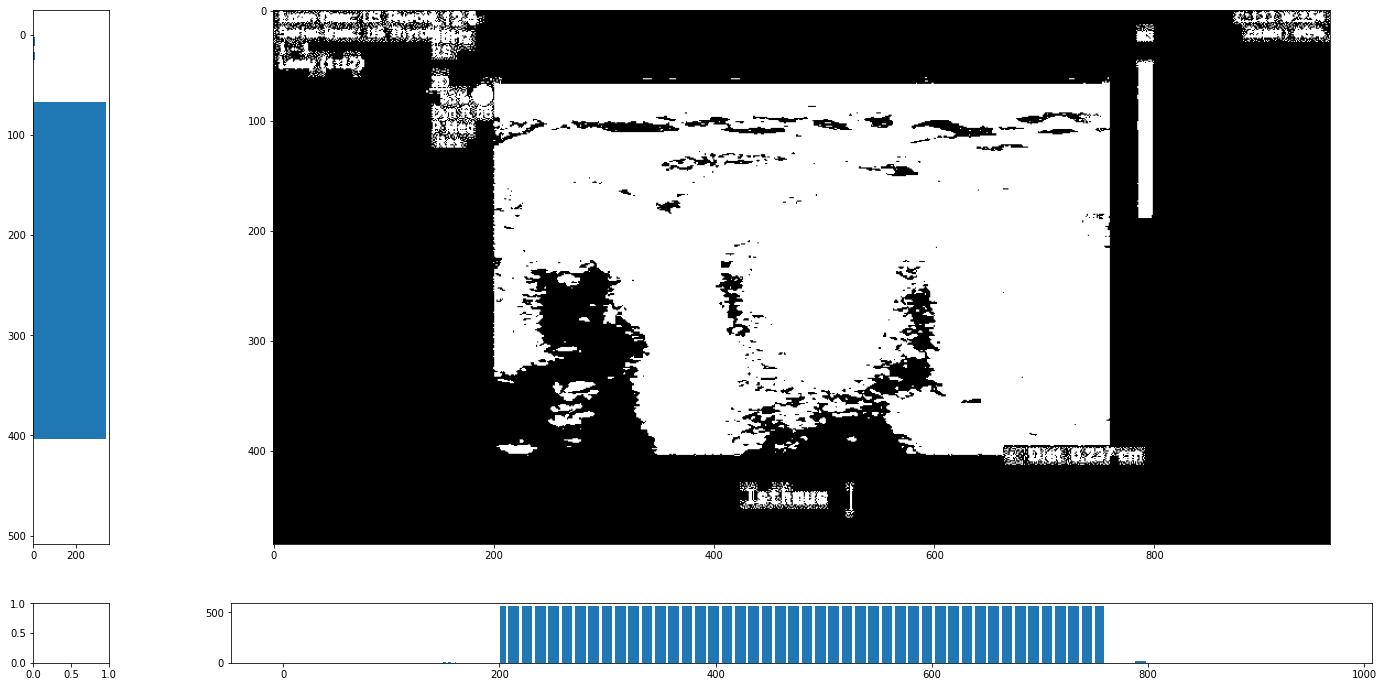

In [4]:
def get_bidirectional_runs(mean_vector):
    forward_runs = get_runs(mean_vector)
    backward_runs = get_runs(mean_vector[::-1])[::-1]
    bidirectional_runs = forward_runs + backward_runs
    return bidirectional_runs

def get_runs(numeric_vector):
    runs = np.empty(len(numeric_vector), dtype=np.int16)
    curr = 0
    for i, x in enumerate(numeric_vector):
        if x > 0.15:
            curr += 1
        else:
            curr = 0
        runs[i] = curr
    return runs

row_runs = get_bidirectional_runs(row_means)
col_runs = get_bidirectional_runs(col_means)

fig, axs = plt.subplots(2, 2, gridspec_kw={'width_ratios': [1, 15], 'height_ratios': [9, 1]})
axs[0, 0].barh(range(len(row_runs)), row_runs)
axs[0, 0].invert_yaxis()
axs[0, 1].imshow(binary_mask, 'gray')
axs[1, 1].bar(range(len(col_runs)), col_runs)
plt.show()

Voila! Suddenly it is very clear exactly where the ultrasound image. The bottom barplot looks discontinuous but its just a plotting artifact, its actually continuous.

Now let's crop the image based on the start and end of the runs.

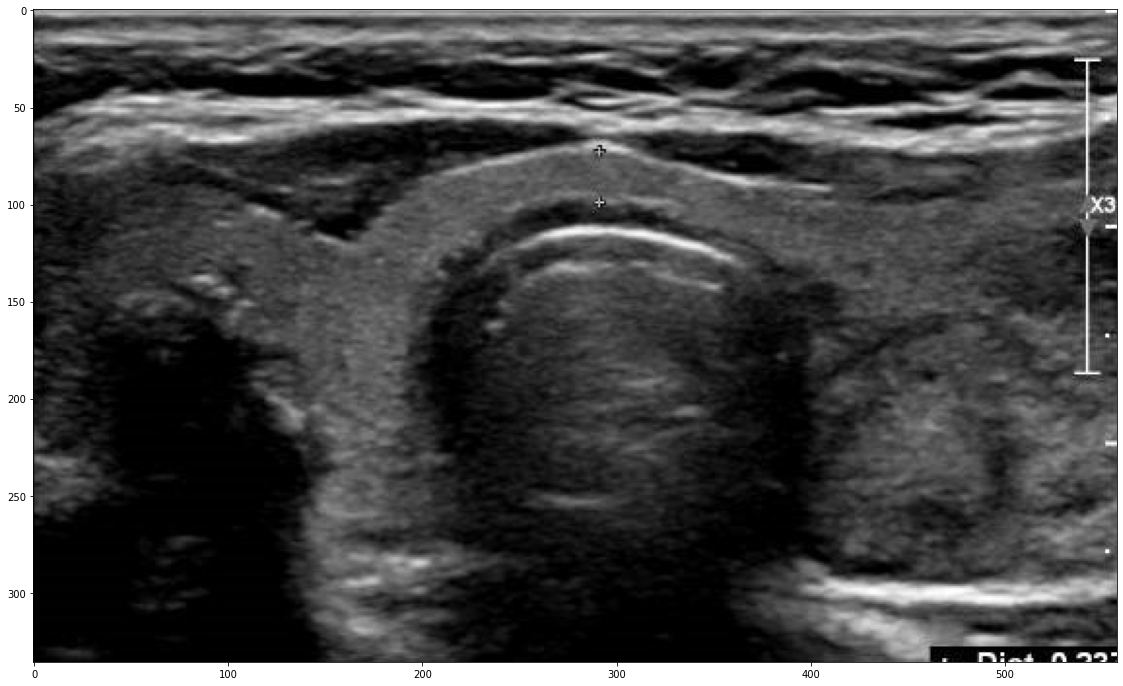

In [5]:
col_indices = np.where(col_runs >= np.max(col_runs)*0.75)[0]
left_bound = col_indices[0]
right_bound = col_indices[-1]
row_indices = np.where(row_runs >= np.max(row_runs)*0.75)[0]
up_bound = row_indices[0]
down_bound = row_indices[-1]
cropped_image = image_array[up_bound:down_bound, left_bound:right_bound]
plt.imshow(cropped_image, 'gray')
plt.show()

Next step is to standardize the shapes of the images. If we just leave the images as is, there would be huge variation in image sizes - some ultrasound images are twice the width of others. To tackle this, we have 3 options.
1. Resize the images to the same shapes and sizes. This is problematic since it would cause the images to no longer be of same aspect ratios and to be of different resolutions.
2. Crop large images to match small ones. This is slightly problematic as some images are much larger than others and we could easily crop out the nodules.
3. Pad the surroundings with black pixels. The size of the actual ultrasound image might be something the model might learn to detect.

I chose to go with option 3. We will standardize the shape to (512, 768).

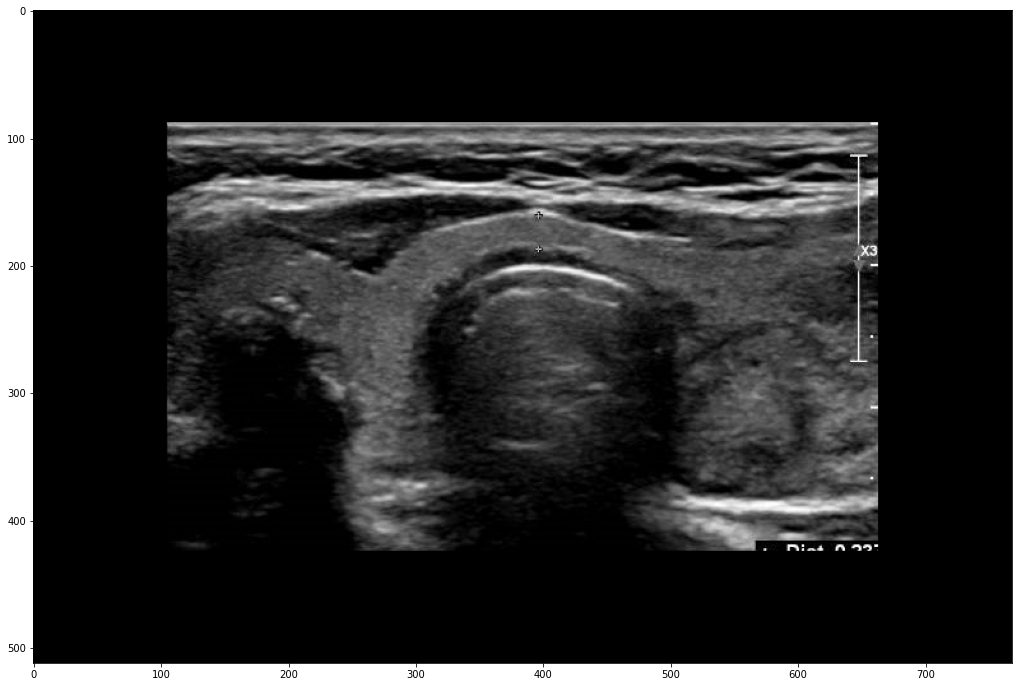

In [6]:
window_size = (512, 768)
resized_image = np.zeros(window_size)
horizontal_boundary = int((window_size[1] - cropped_image.shape[1])/2)
vertical_boundary = int((window_size[0] - cropped_image.shape[0])/2)
resized_image[vertical_boundary:(vertical_boundary+cropped_image.shape[0]), horizontal_boundary:(horizontal_boundary+cropped_image.shape[1])] = cropped_image
plt.imshow(resized_image, 'gray')
plt.show()

### Artifact Removal

This section is slightly contentious. For one, wouldn't it be amazing to magically remove the artifacts overlaying the ultrasound image left over from the cropping? But on the other hand, information does not magically appear and as Kaicheng says, we could be simply "replacing one artifact with another". I believe we can do something.

We have 3 goals:
1. Minimise change to non-artifact regions of the image.
2. Reduce the amount the artifacts standout from the rest of the image.
3. Reduce the consistency of the artifacts, so that while they might still exist, the model would struggle to rely on them to make predictions.

The approach I'm gonna use is based on the fact that the artifacts I want to remove are brighter white than the rest of the image.

The first step is to isolate the regions of the image that are above a certain intensity value. We will continue using the sample image we got from the cropping section above.

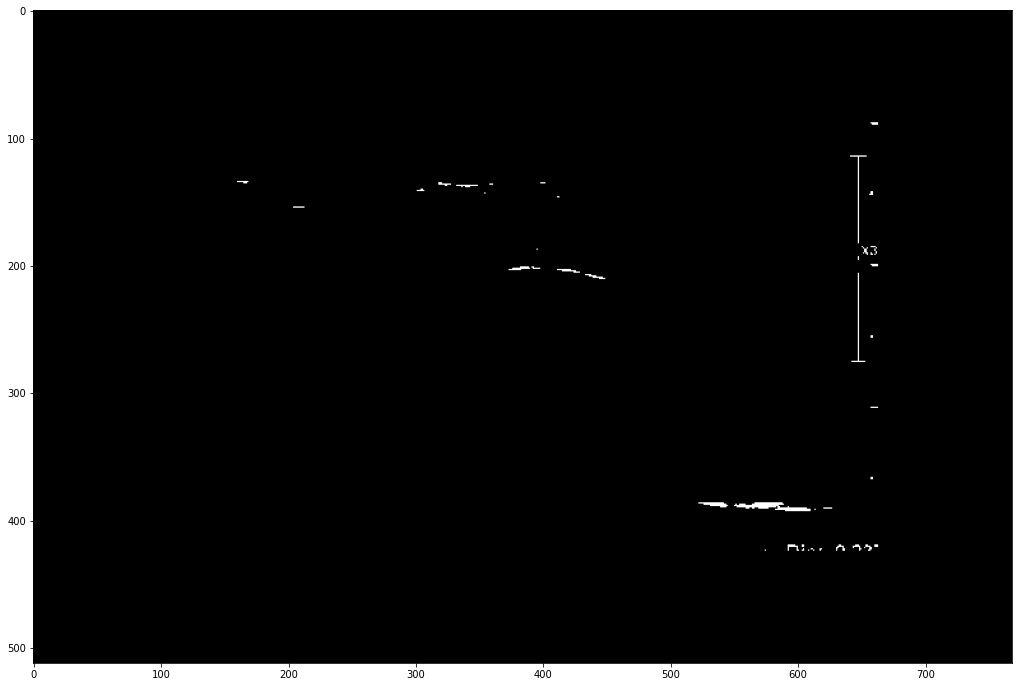

In [7]:
cleaned_image = resized_image.copy()
artifact_flags =cleaned_image >= 230
binary_mask = np.zeros(cleaned_image.shape)
binary_mask[artifact_flags] = 1.
plt.imshow(binary_mask, 'gray')
plt.show()

As we can see, this picks out all of the artifacts. Unfortunately, it also picks out the bright spots in the actual ultrasound image.

The idea now is that these the artifacts are mostly surrounded by pixels that are much darker than themselves, while the non-artifact bright spots would mostly be surrounded by bright pixels as well.

If we simply replace all the pixels picked out above by a local mean of surrounding pixels, we would be able to weaken the artifacts without affecting the non-artifact bright spots.

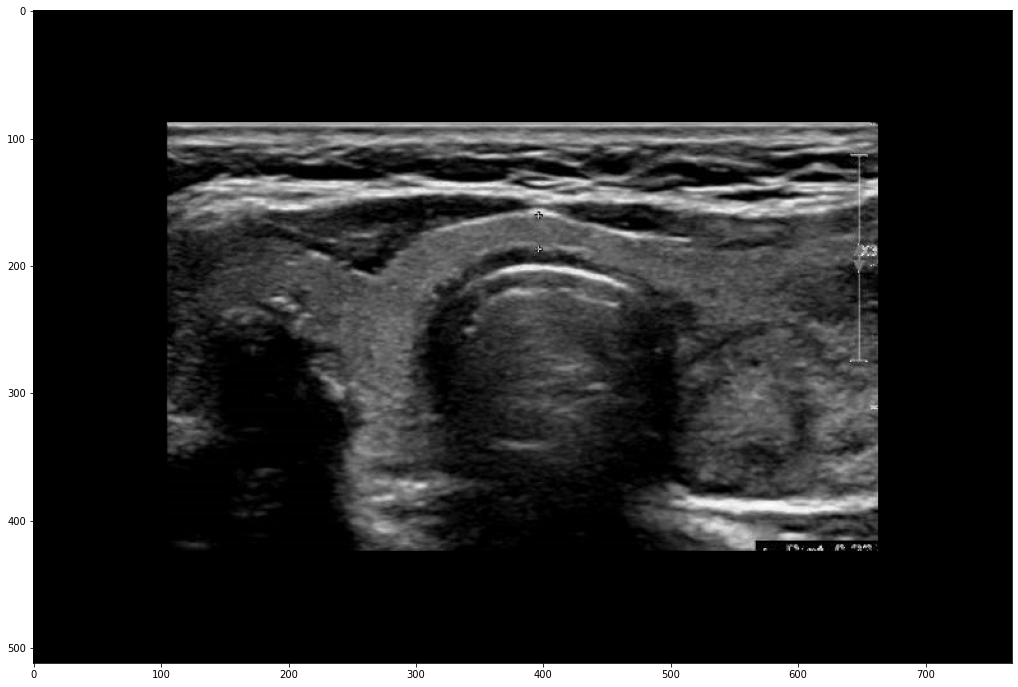

In [8]:
artifact_idx = np.where(artifact_flags)
artifact_idx_list = []
for i, y in enumerate(artifact_idx[0]):
    x = artifact_idx[1][i]
    artifact_idx_list.append((y, x, cleaned_image[y, x]))
artifact_idx_list.sort(key=lambda tup: tup[2], reverse=False)
for y, x, _ in artifact_idx_list:
    local_region = cleaned_image[(y-1):(y+2), (x-1):(x+2)]
    background_mean = np.mean(sorted(local_region.flatten())[:6])
    cleaned_image[y, x] = background_mean
plt.imshow(cleaned_image, 'gray')
plt.show()

Nice! We managed to weaken the artifacts, making it almost translucent, while not affecting the bright spots.

Let's take a closer look to ensure we did a good job.

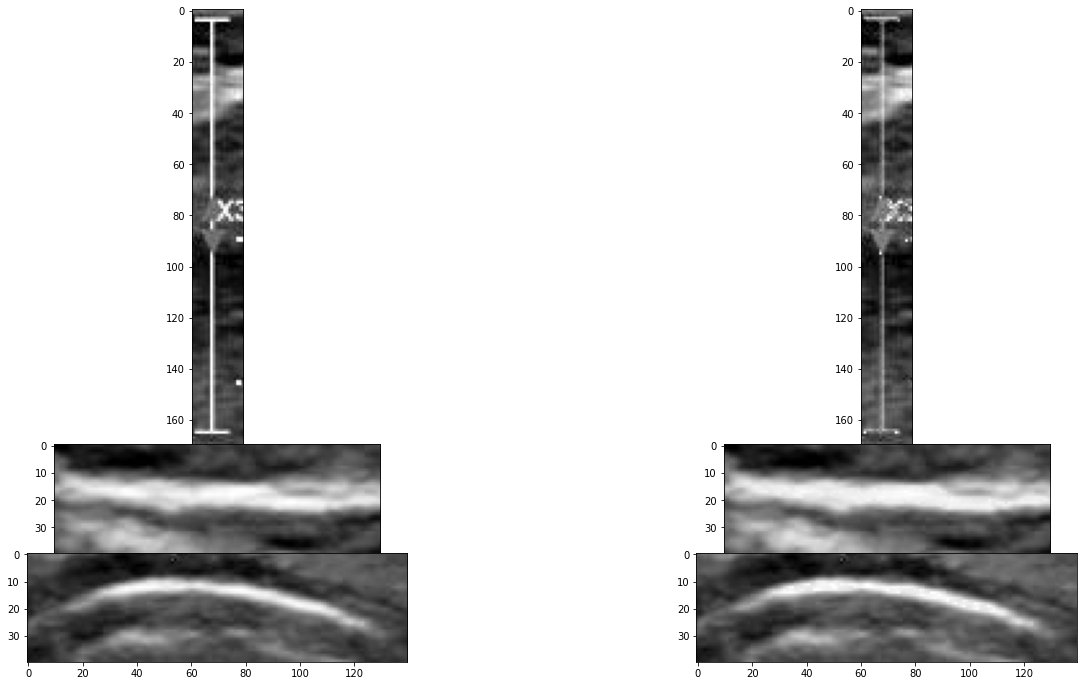

In [9]:
fig, axs = plt.subplots(ncols=2, nrows=3, gridspec_kw={'wspace':0, 'hspace':0, 'height_ratios': [4, 1, 1]})
axs[0, 0].imshow(resized_image[110:280, 640:660], 'gray')
axs[0, 1].imshow(cleaned_image[110:280, 640:660], 'gray')
axs[1, 0].imshow(resized_image[370:410, 510:630], 'gray')
axs[1, 1].imshow(cleaned_image[370:410, 510:630], 'gray')
axs[2, 0].imshow(resized_image[190:230, 340:480], 'gray')
axs[2, 1].imshow(cleaned_image[190:230, 340:480], 'gray')
plt.show()

Left column is the original image, right column is the modified image.

The first row is the artifact we are trying to remove. We can clearly see a big change. The other 2 twos are essentially unchanged.

We've essentially achieved our 3 goals!

### Putting It All Together

Here I define all the constants to be used.

In [31]:
# Cropping Constants
BINARY_THRESHOLD = 1
RUN_THRESHOLD = 0.14
MIN_HEIGHT = 300

# Artifacts Constants
ARTIFACT_INTENSITY = 220

Here are the functions based on what we've explored above.

In [26]:
def load_image(image_path):
    img = cv2.imread(image_path, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img_rgb

def crop_image(image_array, window_size):
    ultrasound_image = find_ultrasound_image(image_array)
    cropped_image = standardize_size(ultrasound_image, window_size)
    return cropped_image

def remove_artifacts(cropped_image):
    artifact_flags = cropped_image >= ARTIFACT_INTENSITY
    artifact_idx = np.where(artifact_flags)
    artifact_idx_list = []
    for i, y in enumerate(artifact_idx[0]):
        x = artifact_idx[1][i]
        artifact_idx_list.append((y, x, cropped_image[y, x]))
    artifact_idx_list.sort(key=lambda tup: tup[2], reverse=False)
    for y, x, _ in artifact_idx_list:
        local_region = cropped_image[(y-1):(y+2), (x-1):(x+2)]
        background_mean = np.mean(sorted(local_region.flatten())[:6])
        cropped_image[y, x] = background_mean
    return cropped_image

def find_ultrasound_image(image_array):
    binary_mask = np.zeros(image_array.shape)
    binary_mask[image_array > BINARY_THRESHOLD] = 1.
    
    row_mean = np.mean(binary_mask, axis=0)
    col_mean = np.mean(binary_mask, axis=1)
    
    row_runs = get_bidirectional_runs(row_mean)
    col_runs = get_bidirectional_runs(col_mean)
    
    row_indices = np.where(row_runs >= np.max(row_runs)*0.75)[0]
    left_bound = row_indices[0]
    right_bound = row_indices[-1]
    col_indices = np.where(col_runs >= np.max(col_runs)*0.75)[0]
    up_bound = col_indices[0]
    down_bound = max(col_indices[-1], up_bound + MIN_HEIGHT)
    cropped_image = image_array[up_bound:down_bound, left_bound:right_bound]
    
    # plt.imshow(binary_mask, 'gray')
    # plt.show()
    # plt.bar(range(len(row_mean)), row_mean)
    # plt.axhline(RUN_THRESHOLD, c='r')
    # plt.show()
    # plt.bar(range(len(row_runs)), row_runs)
    # plt.axhline(np.max(row_runs)*0.75, c='r')
    # plt.show()
    # plt.bar(range(len(col_mean)), col_mean)
    # plt.axhline(RUN_THRESHOLD, c='r')
    # plt.show()
    # plt.bar(range(len(col_runs)), col_runs)
    # plt.axhline(np.max(col_runs)*0.75, c='r')
    # plt.show()
    
    return cropped_image

def standardize_size(ultrasound_image, window_size):
    resized_image = np.zeros(window_size)
    horizontal_boundary = int((window_size[1] - ultrasound_image.shape[1])/2)
    vertical_boundary = int((window_size[0] - ultrasound_image.shape[0])/2)
    resized_image[vertical_boundary:(vertical_boundary+ultrasound_image.shape[0]), 
                  horizontal_boundary:(horizontal_boundary+ultrasound_image.shape[1])] = ultrasound_image
    return resized_image

def get_bidirectional_runs(mean_vector):
    forward_runs = get_runs(mean_vector)
    backward_runs = get_runs(mean_vector[::-1])[::-1]
    bidirectional_runs = forward_runs + backward_runs
    return bidirectional_runs

def get_runs(numeric_vector):
    runs = np.empty(len(numeric_vector), dtype=np.int16)
    curr = 0
    for i, x in enumerate(numeric_vector):
        if x > RUN_THRESHOLD:
            curr += 1
        else:
            curr = 0
        runs[i] = curr
    return runs

def represents_int(s):
    try: 
        int(s)
        return True
    except ValueError:
        return False

Use the functions above to process the images.

In [50]:
data_path = os.path.join('..', 'data', 'structured')
window_size = (512, 768)

aggregate_path = os.path.join(data_path, 'aggregate.csv')
df = pd.read_csv(aggregate_path)
X = np.zeros((len(df), *window_size))

for i, row in df.iterrows():
    image_path = os.path.join(data_path, str(row['sample_id']), row['image'].split('n')[0]+'.png')
    image_array = load_image(image_path)
    cropped_image = crop_image(image_array, window_size)
    cleaned_image = remove_artifacts(cropped_image)
    X[i] = cleaned_image